<a href="https://colab.research.google.com/github/Mark-at/comp551-AppliedMachineLearning/blob/main/comp551_A4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Loading the Dataset

In [ ]:
from datasets import load_dataset

#ds = load_dataset("fancyzhx/ag_news")
train_dataset = load_dataset("fancyzhx/ag_news", split="train")
test_dataset  = load_dataset("fancyzhx/ag_news", split="test")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

In [ ]:
split = train_dataset.train_test_split(test_size=0.1, seed=2026) #use of LLM
train_dataset = split["train"]
val_dataset   = split["test"]

In [ ]:
#use a hash table to map a token to its ID
#make PAD 0 and UNK 1
#if shorter than 128 need to pad it, if longer need to truncate

#use a hash table to map a token to its ID
#make PAD 0 and UNK 1
#if shorter than 128 need to pad it, if longer need to truncate
# class tokenization:
#     def __init__(self):
#         self.mapping = {"PAD": 0, "UNK": 1}
#         #max length = 128
#         #min frequency = 2
#     def splitSentence(self, sentence):
#         l = re.findall(r'\$[\d,.]+|[\w][\w\-]*', sentence.lower())
#         for word in l:
#             if self.mapping.get(word) == None:
#                 self.mapping[word] = 1 #append
#             else:
#                 self.mapping[word] = self.mapping.get(word) + 1
#     def build(self, ds): #builds the vocabulary of the model
#         train_texts = ds["text"]
#         for s in train_texts:
#             self.splitSentence(s)
#         #check for freq
#         for x, y in self.mapping:
#             if y <= 2:
#                 self.mapping.pop(x)

#     def tokenize(self, s):
#         output = []
#         l = re.findall(r'\$[\d,.]+|[\w][\w\-]*', s.lower())
#         for token in l:
#             if token in self.mapping:
#                 output.append(self.mapping.get(token))
#             else:
#                 output.append(1)
#         #check length of 128; or pad the rest by 1.

#used LLM to debug, wrote all the logic from scratch except the counter
import re
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt
import warnings
# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')
# PyTorch imports
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

class Tokenization:
    def __init__(self):
        self.mapping = {"PAD": 0, "UNK": 1}

    def _split(self, sentence): #word-level tokenization
        return re.findall(r'\$[\d,.]+|[\w][\w\-]*', sentence.lower())

    def build(self, ds):
        freq = Counter()
        for sentence in ds["text"]:
            freq.update(self._split(sentence))

        for word, count in freq.items():
            if count > 2 and word not in self.mapping:
                self.mapping[word] = len(self.mapping)

    def tokenize(self, sentence):
        ids = [self.mapping.get(token, 1) for token in self._split(sentence)]
        ids = ids[:128]
        ids = ids + [0] * (128 - len(ids))
        return ids

    @property
    def vocab_size(self):
        return len(self.mapping)

In [ ]:
tok = Tokenization() #use of LLM for debugging
tok.build(train_dataset)  # build vocab on train only

train_sequences = [tok.tokenize(text) for text in train_dataset["text"]]
val_sequences   = [tok.tokenize(text) for text in val_dataset["text"]]
test_sequences  = [tok.tokenize(text) for text in test_dataset["text"]]

y_train = np.array(train_dataset["label"])
y_val   = np.array(val_dataset["label"])
y_test  = np.array(test_dataset["label"])

class CategoryDataset(Dataset): #inspiration taken from tutorial
    def __init__(self, sequences, labels):
        super().__init__()
        self.sequences = torch.LongTensor(sequences)
        self.labels    = torch.LongTensor(labels)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.sequences[idx], self.labels[idx]

trainDS = CategoryDataset(train_sequences, y_train)
valDS   = CategoryDataset(val_sequences,   y_val)
testDS  = CategoryDataset(test_sequences,  y_test)

trainloader = DataLoader(trainDS, batch_size=64, shuffle=True)
valloader   = DataLoader(valDS,   batch_size=64, shuffle=False)
testloader  = DataLoader(testDS,  batch_size=64, shuffle=False)

In [ ]:
class LongShortTermMemoryModel(nn.Module):
  def __init__ (self, d_emb, d_hidden):
    super().__init__()
    self.embedding = nn.Embedding(tok.vocab_size, d_emb)
    self.innerWorkings = nn.LSTM(d_emb, d_hidden, 1, batch_first=True) #number of RNN layers is 1
    self.fc = nn.Linear(d_hidden, 4) # 4 logits
    self.d_hidden = d_hidden
  def forward(self, x):
    embedded = self.embedding(x)
    mask = (x!=0)
    output, (hidden, cell) = self.innerWorkings(embedded)

    #used LLM here
    sum_hidden = (output * mask.unsqueeze(-1)).sum(dim=1)  # (batch_size, d_hidden)
    word_counts = mask.sum(dim=1, keepdim=True)  # (batch_size, 1)

    pooled = sum_hidden / word_counts
    return self.fc(pooled)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model  = LongShortTermMemoryModel(128, 256).to(device)




In [ ]:
total = sum(p.numel() for p in model.parameters())
print(f"Total params: {total}")

Total params: 5294980


In [ ]:
#the following block is mostly from the code review
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=0.001)

# Number of training epochs (reduced since we have more data)
num_epochs = 6

# Lists to store training history
train_losses = []
val_losses = []
val_accuracies = []

print('Starting training...')
print(f'Batches per epoch: {len(trainloader)}')

#fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
#sns.set_theme(style="whitegrid")

for epoch in range(num_epochs):
    # ===== Training phase =====
    model.train()  # Set model to training mode (enables dropout)

    epoch_training_loss = 0.0

    epoch_val_loss = 0.0
    valCorrect = 0
    valTotal = 0


    # Iterate over training batches
    for i, (sequences, labels) in enumerate(trainloader):
        # Move data to device
        sequences = sequences.to(device)
        labels = labels.to(device)
        # Zero the gradients from previous iteration
        optimizer.zero_grad()
        # Forward pass: get predictions
        outputs = model(sequences)
        # Compute loss
        loss = criterion(outputs, labels)
        # Backward pass: compute gradients via backpropagation through time (BPTT)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)# Gradient clipping
        optimizer.step()

        # Accumulate statistics
        epoch_training_loss += loss.item()

    model.eval()
    with torch.no_grad(): #no need to update gradient in validaiton so disable it
      for i, (sequences, labels) in enumerate(valloader):
          # Move data to device
          sequences = sequences.to(device)
          labels = labels.to(device)
          # Forward pass: get predictions
          outputs = model(sequences)
          # Compute loss
          loss = criterion(outputs, labels)
          # Accumulate statistics
          epoch_val_loss += loss.item()
          _, predicted = torch.max(outputs, dim=1)
          valTotal += labels.size(0)
          valCorrect += (predicted == labels).sum().item()



    # Calculate average loss and accuracy for this epoch
    avg_loss = epoch_training_loss / len(trainloader)
    avg_val_loss = epoch_val_loss / len(valloader)
    val_accuracy = 100 * valCorrect / valTotal

    # Store history
    train_losses.append(avg_loss)
    val_losses.append(avg_val_loss)
    val_accuracies.append(val_accuracy)

    print(f'Epoch [{epoch+1:2d}/{num_epochs}] - Loss: {avg_loss:.4f} - Val Loss: {avg_val_loss:.4f}, Val Acc: {val_accuracy:5.2f}%')

print('\nTraining complete!')

Starting training...
Batches per epoch: 1688
Epoch [ 1/6] - Loss: 0.4541 - Val Loss: 0.3164, Val Acc: 89.28%
Epoch [ 2/6] - Loss: 0.2387 - Val Loss: 0.2641, Val Acc: 90.92%
Epoch [ 3/6] - Loss: 0.1673 - Val Loss: 0.2689, Val Acc: 91.06%
Epoch [ 4/6] - Loss: 0.1117 - Val Loss: 0.2783, Val Acc: 90.92%
Epoch [ 5/6] - Loss: 0.0691 - Val Loss: 0.3244, Val Acc: 90.67%
Epoch [ 6/6] - Loss: 0.0420 - Val Loss: 0.4095, Val Acc: 90.30%

Training complete!


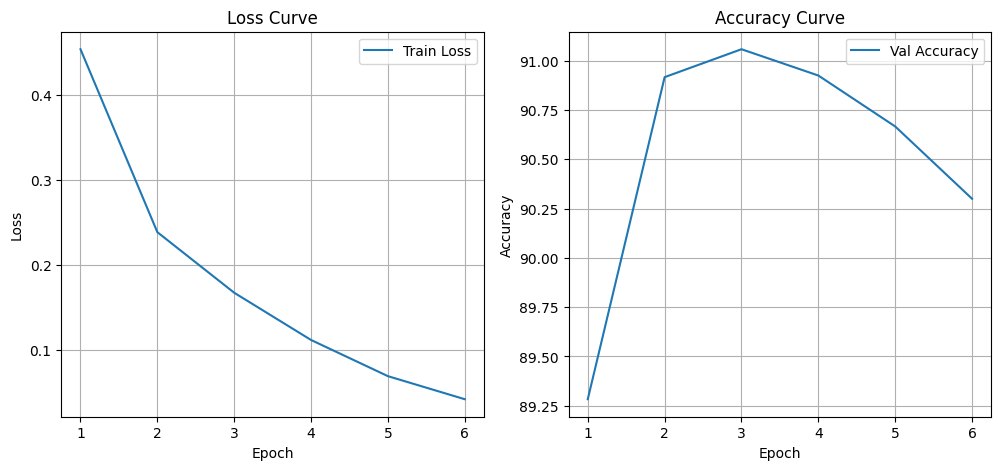

In [ ]:
x = [1,2,3,4,5,6]
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(x, train_losses, label='Train Loss')
#plt.plot(val_losses, label='Val Loss')
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(x, val_accuracies, label='Val Accuracy')
#if history['val_acc']:
 #   plt.plot(history['val_acc'], label='Val Accuracy')
plt.title('Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

In [ ]:

# Evaluate on test set

model.eval()  # Set to evaluation mode

num = 0
id2word = {idx: word for word, idx in tok.mapping.items()}

test_correct = 0
test_total = 0
test_loss = 0.0

# Store predictions for detailed analysis
all_predictions = []
all_labels = []

# Disable gradient computation for evaluation (saves memory)
with torch.no_grad():
    for sequences, labels in testloader:
        # Move to device
        sequences = sequences.to(device)
        labels = labels.to(device)

        # Get predictions
        outputs = model(sequences)

        # Compute loss
        loss = criterion(outputs, labels)
        test_loss += loss.item()

        # Get predicted class
        _, predicted = torch.max(outputs, dim=1)

        # Store predictions and labels
        all_predictions.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

        # Count correct predictions
        test_total += labels.size(0)
        test_correct += (predicted == labels).sum().item()
        # while num <= 5:
        #   for prediction in predicted:
        #     if prediction != labels:
        #       print('sequences, correct label = , predicted')


        # Show misclassified examples; used LLM to refine the code (finding the sentence from sequences)
        for i in range(len(predicted)):
            if predicted[i] != labels[i] and num < 6:
                seq_ids = sequences[i].cpu().numpy()

                tokens = [
                    id2word.get(idx, "<UNK>")
                    for idx in seq_ids
                    if idx != 0
                ]

                print("Text:", " ".join(tokens))
                print("True:", labels[i].item())
                print("Pred:", predicted[i].item())
                print("-----")

                num += 1

# Calculate metrics
test_accuracy = 100 * test_correct / test_total
avg_test_loss = test_loss / len(testloader)

print(f'Test Loss: {avg_test_loss:.4f}')
print(f'Test Accuracy: {test_accuracy:.2f}%')
print(f'Correct: {test_correct}/{test_total}')



Text: fears for t n pension after talks unions representing workers at turner newall say they are disappointed after talks with stricken parent firm federal mogul
True: 2
Pred: 0
-----
Text: prediction unit helps forecast UNK ap ap it s barely dawn when mike fitzpatrick starts his shift with a blur of colorful maps figures and endless charts but already he knows what the day will bring lightning will strike in places he expects winds will pick up UNK places will dry and flames will roar
True: 3
Pred: 1
-----
Text: card fraud unit nets 36 000 cards in its first two years the uk s dedicated card fraud unit has recovered 36 000 stolen cards and 171 arrests and estimates it saved UNK
True: 3
Pred: 2
-----
Text: super ant colony hits australia a giant 100km colony of ants which has been discovered in melbourne australia could threaten local insect species
True: 3
Pred: 0
-----
Text: some people not eligible to get in on google ipo google has billed its ipo as a way for everyday people to ge

extra for task 1 (last hidden + gru)

In [ ]:
results = test_dataset.filter(lambda x: "ant colony" in x["text"].lower())
for r in results:
    print(r["text"])
    print("---")

Filter:   0%|          | 0/7600 [00:00<?, ? examples/s]

Super ant colony hits Australia A giant 100km colony of ants  which has been discovered in Melbourne, Australia, could threaten local insect species.
---


In [ ]:
class RecurrentClassifier(nn.Module):
    def __init__(self, vocab_size, d_emb, d_hidden, rnn_type="lstm", pooling="mean", pad_idx=0):
        super().__init__()
        assert rnn_type in ("lstm", "gru")
        assert pooling in ("mean", "last")
        self.rnn_type = rnn_type
        self.pooling = pooling
        self.pad_idx = pad_idx

        self.embedding = nn.Embedding(vocab_size, d_emb, padding_idx=pad_idx)
        rnn_cls = nn.LSTM if rnn_type == "lstm" else nn.GRU
        self.rnn = rnn_cls(d_emb, d_hidden, num_layers=1, batch_first=True)
        self.fc = nn.Linear(d_hidden, 4)

    def forward(self, x):
        mask = (x != self.pad_idx)
        lengths = mask.sum(dim=1).clamp(min=1)
        embedded = self.embedding(x)
        output, _ = self.rnn(embedded)

        if self.pooling == "mean":
            #mean pooling
            summed = (output * mask.unsqueeze(-1)).sum(dim=1)
            pooled = summed / lengths.unsqueeze(-1)
        else:
            #last
            idx = (lengths - 1).view(-1, 1, 1).expand(-1, 1, output.size(-1))
            pooled = output.gather(dim=1, index=idx).squeeze(1)

        return self.fc(pooled)

In [ ]:
def train_and_eval(rnn_type, pooling, num_epochs=6, lr=1e-3):
    torch.manual_seed(2026)
    model = RecurrentClassifier(tok.vocab_size, 128, 256,
                                rnn_type=rnn_type, pooling=pooling).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    tag = f"{rnn_type.upper()}+{pooling}"
    print(f"\n training {tag} ")

    for epoch in range(num_epochs):
        model.train()
        tr_loss = 0.0
        for seqs, labels in trainloader:
            seqs, labels = seqs.to(device), labels.to(device)
            optimizer.zero_grad()
            loss = criterion(model(seqs), labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            tr_loss += loss.item()

        model.eval()
        v_loss, correct, total = 0.0, 0, 0
        with torch.no_grad():
            for seqs, labels in valloader:
                seqs, labels = seqs.to(device), labels.to(device)
                out = model(seqs)
                v_loss += criterion(out, labels).item()
                correct += (out.argmax(1) == labels).sum().item()
                total += labels.size(0)

        print(f"Epoch {epoch+1}: "
              f"train_loss={tr_loss/len(trainloader):.4f} "
              f"val_loss={v_loss/len(valloader):.4f} "
              f"val_acc={correct/total:.4f}")

    return model, tag

In [ ]:
def evaluate_on_test(model, tag):
    model.eval()
    criterion = nn.CrossEntropyLoss()
    id2word = {idx: word for word, idx in tok.mapping.items()}

    test_correct, test_total, test_loss = 0, 0, 0.0
    all_predictions, all_labels = [], []
    num = 0
    print(f"\nTest results for {tag}")

    with torch.no_grad():
        for sequences, labels in testloader:
            sequences = sequences.to(device)
            labels = labels.to(device)

            outputs = model(sequences)
            loss = criterion(outputs, labels)
            test_loss += loss.item()

            _, predicted = torch.max(outputs, dim=1)
            all_predictions.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            test_total += labels.size(0)
            test_correct += (predicted == labels).sum().item()
            for i in range(len(predicted)):
                if predicted[i] != labels[i] and num < 6:
                    seq_ids = sequences[i].cpu().numpy()
                    tokens = [id2word.get(idx, "<UNK>") for idx in seq_ids if idx != 0]
                    print("Text:", " ".join(tokens))
                    print("True:", labels[i].item())
                    print("Pred:", predicted[i].item())
                    print("-----")
                    num += 1

    test_accuracy = 100 * test_correct / test_total
    avg_test_loss = test_loss / len(testloader)
    print(f"Test Loss: {avg_test_loss:.4f}")
    print(f"Test Accuracy: {test_accuracy:.2f}%")
    print(f"Correct: {test_correct}/{test_total}")
    return test_accuracy

In [ ]:
results = {}
for rnn_type, pooling in [("lstm", "last"), ("gru", "mean")]:
    trained_model, tag = train_and_eval(rnn_type, pooling)
    results[tag] = evaluate_on_test(trained_model, tag)

print("\n=== Summary: Test Accuracy ===")
for name, acc in results.items():
    print(f"  {name:15s}  {acc:.2f}%")


 training LSTM+last 
Epoch 1: train_loss=0.5217 val_loss=0.3298 val_acc=0.8925
Epoch 2: train_loss=0.2692 val_loss=0.2836 val_acc=0.9066
Epoch 3: train_loss=0.1949 val_loss=0.2746 val_acc=0.9093
Epoch 4: train_loss=0.1390 val_loss=0.2783 val_acc=0.9143
Epoch 5: train_loss=0.0938 val_loss=0.2996 val_acc=0.9117
Epoch 6: train_loss=0.0585 val_loss=0.3729 val_acc=0.9055

Test results for LSTM+last
Text: super ant colony hits australia a giant 100km colony of ants which has been discovered in melbourne australia could threaten local insect species
True: 3
Pred: 0
-----
Text: UNK unite dolphin groups dolphin groups or UNK rely on UNK to keep them from collapsing scientists claim
True: 3
Pred: 0
-----
Text: teenage t rex s monster growth tyrannosaurus rex achieved its massive size due to an enormous growth spurt during its adolescent years
True: 3
Pred: 2
-----
Text: ibm to hire even more new workers by the end of the year the computing giant plans to have its biggest UNK since 1991
True: 3


Task2

Tokenization

In [ ]:
from transformers import AutoTokenizer

#load the tokenizer for distilbert-base-uncased
checkpoint = "distilbert-base-uncased"
transformer_tokenizer = AutoTokenizer.from_pretrained(checkpoint)

#define the tokenize function
def tokenize_function(examples):
    return transformer_tokenizer(
        examples['text'],
        padding = 'max_length',
        truncation = True,
        max_length = 128
    )

#tokenize the datasets
tokenized_train_dataset = train_dataset.map(tokenize_function, batched = True)
tokenized_val_dataset = val_dataset.map(tokenize_function, batched = True)
tokenized_test_dataset = test_dataset.map(tokenize_function, batched = True)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/108000 [00:00<?, ? examples/s]

Map:   0%|          | 0/12000 [00:00<?, ? examples/s]

Map:   0%|          | 0/7600 [00:00<?, ? examples/s]

In [ ]:
#example comparing tokenizers
sentence = "The unbelievably shocking news arrived."
#word-level tokenizer
tok.tokenize(sentence)

[61,
 36947,
 10696,
 516,
 4889,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0]

In [ ]:
#transformer tokenizer
transformer_tokenizer(sentence)

{'input_ids': [101, 1996, 4895, 8671, 2666, 3567, 6321, 16880, 2739, 3369, 1012, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}

The model

In [ ]:
from transformers import AutoModelForSequenceClassification
! pip install evaluate #run this if evaluate is not installed
import evaluate

model = AutoModelForSequenceClassification.from_pretrained(checkpoint, num_labels = 4)

#add the metric for accuracy
metric = evaluate.load("accuracy")

def compute_accuracy(eval_preds):
    logits, labels = eval_preds
    predictions = np.argmax(logits, axis=-1)
    return metric.compute(predictions=predictions, references=labels)

print("\n")
print(f"The number of parameters is {model.num_parameters():,}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 6.1 MB/s eta 0:00:00


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.




The number of parameters is 66,956,548


Training

In [ ]:
from transformers import TrainingArguments, Trainer

training_args = TrainingArguments(
    output_dir="./results",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.05,
    optim="adamw_torch",
    eval_strategy="epoch",
    fp16=True,
    save_strategy="no"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train_dataset,
    eval_dataset=tokenized_val_dataset,
    compute_metrics=compute_accuracy
)

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,0.203686,0.169763,0.943917
2,0.142635,0.181770,0.947500
3,0.090625,0.201463,0.951167


TrainOutput(global_step=20250, training_loss=0.15875777755548925, metrics={'train_runtime': 1526.3647, 'train_samples_per_second': 212.269, 'train_steps_per_second': 13.267, 'total_flos': 1.0730241994752e+16, 'train_loss': 0.15875777755548925, 'epoch': 3.0})

Evaluate on the test set

In [ ]:
test_results = trainer.evaluate(tokenized_test_dataset)
test_results

{'eval_loss': 0.2148618847131729,
 'eval_accuracy': 0.9475,
 'eval_runtime': 8.1918,
 'eval_samples_per_second': 927.754,
 'eval_steps_per_second': 57.985,
 'epoch': 3.0}

Misclassified examples

In [ ]:
predictions_output = trainer.predict(tokenized_test_dataset)

predicted_classes = np.argmax(predictions_output.predictions, axis=1)
true_classes = predictions_output.label_ids

label_map = {0: "World", 1: "Sports", 2: "Business", 3: "Sci/Tech"}

misclassified_indices = np.where(predicted_classes != true_classes)[0]

print(f"\nFound {len(misclassified_indices)} misclassified examples out of {len(test_dataset)}.")
print("Displaying 5 examples for your report's qualitative analysis:\n")
print("-" * 60)

for i in range(min(5, len(misclassified_indices))):
    idx = int(misclassified_indices[i])

    # Grab the original, readable text from the raw test dataset
    original_text = test_dataset[idx]['text']

    # Map the integer IDs back to readable string labels
    true_label = label_map[true_classes[idx]]
    pred_label = label_map[predicted_classes[idx]]

    print(f"Example {i+1}:")
    print(f"(1) Input text: {original_text}")
    print(f"(2) True label: {true_label}")
    print(f"(3) Predicted label: {pred_label}")
    print("-" * 60)


Found 399 misclassified examples out of 7600.
Displaying 5 examples for your report's qualitative analysis:

------------------------------------------------------------
Example 1:
(1) Input text: Some People Not Eligible to Get in on Google IPO Google has billed its IPO as a way for everyday people to get in on the process, denying Wall Street the usual stranglehold it's had on IPOs. Public bidding, a minimum of just five shares, an open process with 28 underwriters - all this pointed to a new level of public participation. But this isn't the case.
(2) True label: Sci/Tech
(3) Predicted label: Business
------------------------------------------------------------
Example 2:
(1) Input text: Venezuela Prepares for Chavez Recall Vote Supporters and rivals warn of possible fraud; government says Chavez's defeat could produce turmoil in world oil market.
(2) True label: World
(3) Predicted label: Business
------------------------------------------------------------
Example 3:
(1) Input tex

Drawing the training curves

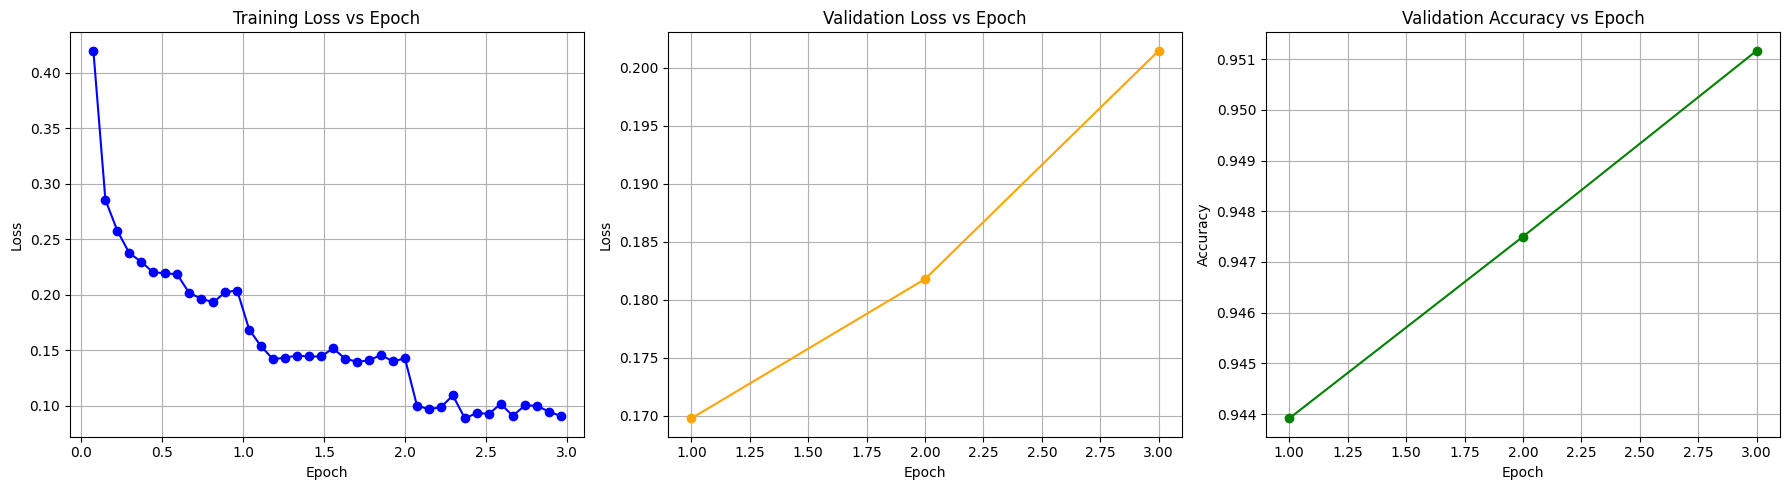

In [ ]:
import matplotlib.pyplot as plt

log_history = trainer.state.log_history

train_epochs, train_loss = [], []
val_epochs, val_loss, val_accuracy = [], [], []

for log in log_history:
    if "loss" in log:
        train_epochs.append(log["epoch"])
        train_loss.append(log["loss"])
    elif "eval_loss" in log:
        val_epochs.append(log["epoch"])
        val_loss.append(log["eval_loss"])
        val_accuracy.append(log["eval_accuracy"])

val_epochs = val_epochs[:3]
val_loss = val_loss[:3]
val_accuracy = val_accuracy[:3]

fig, axs = plt.subplots(1, 3, figsize=(18, 5))

# Plot A: Training Loss vs Epoch
axs[0].plot(train_epochs, train_loss, label="Training Loss", color='blue', marker='o')
axs[0].set_title("Training Loss vs Epoch")
axs[0].set_xlabel("Epoch")
axs[0].set_ylabel("Loss")
axs[0].grid(True)

# Plot B: Validation Loss vs Epoch
axs[1].plot(val_epochs, val_loss, label="Validation Loss", color='orange', marker='o')
axs[1].set_title("Validation Loss vs Epoch")
axs[1].set_xlabel("Epoch")
axs[1].set_ylabel("Loss")
axs[1].grid(True)

# Plot C: Validation Accuracy vs Epoch
axs[2].plot(val_epochs, val_accuracy, label="Validation Accuracy", color='green', marker='o')
axs[2].set_title("Validation Accuracy vs Epoch")
axs[2].set_xlabel("Epoch")
axs[2].set_ylabel("Accuracy")
axs[2].grid(True)

plt.tight_layout()
plt.show()


Extra experiment: Using LoRA

In [ ]:
!pip install -q peft
from peft import LoraConfig, get_peft_model, TaskType

#base model
lora_base = AutoModelForSequenceClassification.from_pretrained(checkpoint, num_labels=4)

lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=8,
    lora_alpha=16,
    lora_dropout=0.1,
    bias="none",
    target_modules=["q_lin", "v_lin"],
)

lora_model = get_peft_model(lora_base, lora_config)
lora_model.print_trainable_parameters()

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


trainable params: 741,124 || all params: 67,697,672 || trainable%: 1.0948


In [ ]:
lora_training_args = TrainingArguments(
    learning_rate=2e-4,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.05,
    optim="adamw_torch",
    eval_strategy="epoch",
    save_strategy="no",
    fp16=True,
    report_to="none",
)

lora_trainer = Trainer(
    model=lora_model,
    args=lora_training_args,
    train_dataset=tokenized_train_dataset,
    eval_dataset=tokenized_val_dataset,
    compute_metrics=compute_accuracy,
)

lora_trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,0.214319,0.193636,0.934750
2,0.184861,0.181036,0.938750
3,0.156044,0.178432,0.943000


TrainOutput(global_step=20250, training_loss=0.20025729181737076, metrics={'train_runtime': 915.524, 'train_samples_per_second': 353.896, 'train_steps_per_second': 22.118, 'total_flos': 1.091465736192e+16, 'train_loss': 0.20025729181737076, 'epoch': 3.0})

In [ ]:
lora_test_results = lora_trainer.evaluate(tokenized_test_dataset)
print("LoRA test results:", lora_test_results)

#Misclassified examples
lora_preds_output = lora_trainer.predict(tokenized_test_dataset)
lora_pred_classes = np.argmax(lora_preds_output.predictions, axis=1)
lora_true_classes = lora_preds_output.label_ids

label_map = {0: "World", 1: "Sports", 2: "Business", 3: "Sci/Tech"}
mis_idx = np.where(lora_pred_classes != lora_true_classes)[0]

print(f"\n[LoRA] Misclassified: {len(mis_idx)} / {len(test_dataset)}")

for i in range(min(5, len(mis_idx))):
    idx = int(mis_idx[i])
    print(f"Example {i+1}:")
    print(f"(1) Input text: {test_dataset[idx]['text']}")
    print(f"(2) True label: {label_map[lora_true_classes[idx]]}")
    print(f"(3) Predicted label: {label_map[lora_pred_classes[idx]]}")


LoRA test results: {'eval_loss': 0.18520735204219818, 'eval_accuracy': 0.94, 'eval_runtime': 13.776, 'eval_samples_per_second': 551.684, 'eval_steps_per_second': 34.48, 'epoch': 3.0}

[LoRA] Misclassified: 456 / 7600
Example 1:
(1) Input text: Some People Not Eligible to Get in on Google IPO Google has billed its IPO as a way for everyday people to get in on the process, denying Wall Street the usual stranglehold it's had on IPOs. Public bidding, a minimum of just five shares, an open process with 28 underwriters - all this pointed to a new level of public participation. But this isn't the case.
(2) True label: Sci/Tech
(3) Predicted label: Business
Example 2:
(1) Input text: Rivals Try to Turn Tables on Charles Schwab By MICHAEL LIEDTKE     SAN FRANCISCO (AP) -- With its low prices and iconoclastic attitude, discount stock broker Charles Schwab Corp. (SCH) represented an annoying stone in Wall Street's wing-tipped shoes for decades...
(2) True label: Sci/Tech
(3) Predicted label: Busi